In [1]:
from sklearn.preprocessing import StandardScaler
from utils import *
from dnn import DNN
from linear_regression import LinearRegressionTorch 

## Load data

In [2]:
data_path = '../data/processed/'
X_train = load_data(f'{data_path}/X_train.csv').values
X_val = load_data(f'{data_path}/X_val.csv').values
X_test = load_data(f'{data_path}/X_test.csv').values
y_train = load_data(f'{data_path}/y_train.csv').values
y_val = load_data(f'{data_path}/y_val.csv').values
y_test = load_data(f'{data_path}/y_test.csv').values

In [3]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

## Training and Evaluation

In [4]:
def pipeline(model, epochs=50):
    train_losses, val_losses = model.fit(X_train, y_train, X_val, y_val, epochs=epochs)
    test_model(model, X_test, y_test)
    plot_loss(train_losses, val_losses)

In [5]:
epochs = 500

### Linear Regression

Epoch [50/500], Train Loss: 378.9268, Val Loss: 379.6088
Epoch [100/500], Train Loss: 374.3225, Val Loss: 377.1613
Epoch [150/500], Train Loss: 372.7238, Val Loss: 376.7269
Epoch [200/500], Train Loss: 372.0317, Val Loss: 376.6392
Epoch [250/500], Train Loss: 371.6989, Val Loss: 376.6249
Epoch [300/500], Train Loss: 371.5225, Val Loss: 376.6111
Epoch [350/500], Train Loss: 371.4206, Val Loss: 376.5836
Epoch [400/500], Train Loss: 371.3573, Val Loss: 376.5447
Epoch [450/500], Train Loss: 371.3160, Val Loss: 376.5003
Epoch [500/500], Train Loss: 371.2882, Val Loss: 376.4549

========= Model Evaluation =========
Mean Squared Error (MSE): 351.6371
R^2 Score: 0.5460


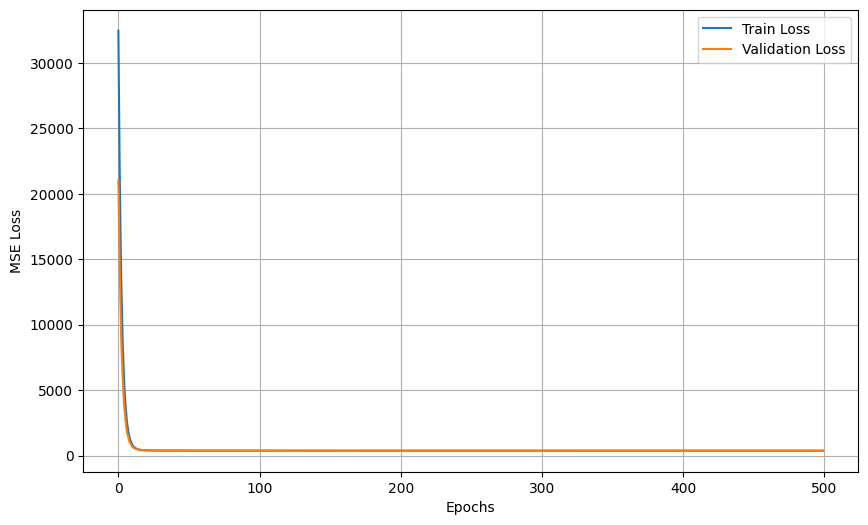

In [6]:
lr = LinearRegressionTorch(X_train.shape[1], lr=0.1)
pipeline(lr, epochs=epochs)

### DNN-16

In [7]:
dnn_16 = DNN(
    input_dim=X_train.shape[1],
    hidden_layers=[16],
    output_dim=1,
    lr=0.001,
)
dnn_16.model

Sequential(
  (0): Linear(in_features=31, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=1, bias=True)
)

Epoch [50/500], Train Loss: 833.7046, Val Loss: 897.0404
Epoch [100/500], Train Loss: 480.9267, Val Loss: 523.6500
Epoch [150/500], Train Loss: 668.0510, Val Loss: 705.3864
Epoch [200/500], Train Loss: 409.1739, Val Loss: 452.1810
Epoch [250/500], Train Loss: 411.6138, Val Loss: 452.6835
Epoch [300/500], Train Loss: 365.6353, Val Loss: 404.3964
Epoch [350/500], Train Loss: 368.3254, Val Loss: 406.3035
Epoch [400/500], Train Loss: 367.5661, Val Loss: 406.0721
Epoch [450/500], Train Loss: 352.0204, Val Loss: 392.1996
Epoch [500/500], Train Loss: 354.0814, Val Loss: 397.0440

========= Model Evaluation =========
Mean Squared Error (MSE): 351.6354
R^2 Score: 0.5460


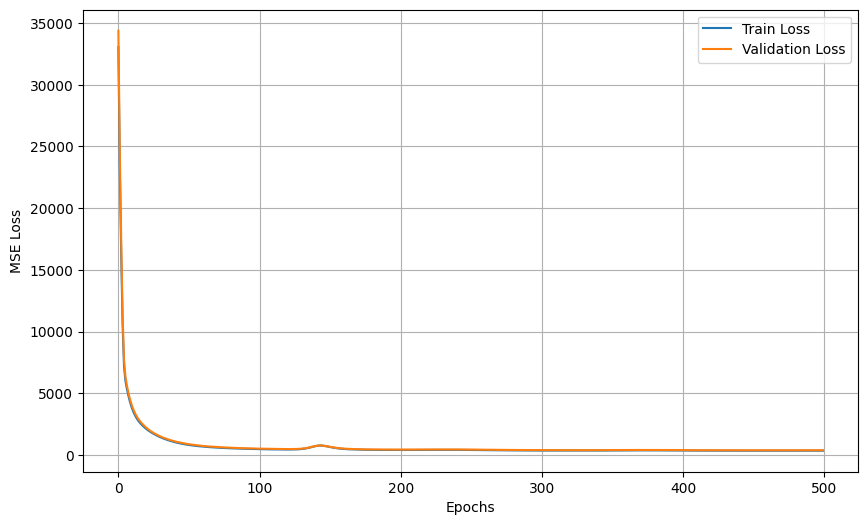

In [8]:
pipeline(dnn_16, epochs=epochs)